In [58]:
from geometry import *

import numpy as np
import matplotlib.pyplot as plt

In [59]:
# 材料定义
vacuum = Material(material_type_vacuum, 'vacuum', {})
electrode_top = Material(material_type_metal, 'top electrode', {})
electrode_bottom = Material(material_type_metal, 'bottom electrode', {})
wall = Material(material_type_metal, 'wall', {})
dielectric_1 = Material(material_type_dielectric, 'dielectric 1', {
                        'permittivity': 2.1, 'permeability': 1.0, 'conductivity': 1.0})
dielectric_2 = Material(material_type_dielectric, 'dielectric 2', {
                        'permittivity': 2.1, 'permeability': 1.0, 'conductivity': 1.0})

In [60]:
# 几何定义
k = 30
# m = 18
higth = int(6.5 * k)
width = 10 * k

Nz = higth + 1
Nr = width + 1
geom = Geometry(Nz, Nr)
geom.add_material([vacuum, electrode_top, electrode_bottom, wall, dielectric_1])

geom.add_rectangles(Rectangle(0, 0, higth, width), vacuum.name)

geom.add_rectangles(Rectangle(0, 0, 2*k, 8*k), electrode_bottom.name)
# geom.add_rectangles(Rectangle(3*k, k, k, 14*k), electrode_bottom.name)

geom.add_rectangles(Rectangle(higth - 2*k, 0, 2*k, 8*k), electrode_top.name)
# geom.add_rectangles(Rectangle(higth - 2*k, 0, 2*k, k), electrode_top.name)

geom.add_rectangles(Rectangle(0, width-9, higth, width), wall.name)
geom.add_rectangles(Rectangle(0, 8*k+9, 2*k, 9*k+24), wall.name)
geom.add_rectangles(Rectangle(higth - 2*k, 8*k+9, higth, 9*k+24), wall.name)

# geom.add_rectangles(Rectangle(0, 15*k, 4*k, 3*k), dielectric_1.name)
# geom.add_rectangles(Rectangle(0, k, 3*k, 14*k), dielectric_1.name)
# geom.add_rectangles(Rectangle(higth - 2*k, 18*k, m, 5*k - 1), dielectric_1.name)

geom.add_diag_edf(Rectangle(1, 1, higth - 2, width - 2))
geom.add_diag_flux(Hline(higth - 2 * k, 0, 5 * k))

hf = 3
geom.add_diag_edf(Rectangle(60-hf, 50, hf*2, hf*2))
geom.add_diag_edf(Rectangle(60-hf, 130, hf*2, hf*2))
geom.add_diag_edf(Rectangle(40-hf, 50, hf*2, hf*2))



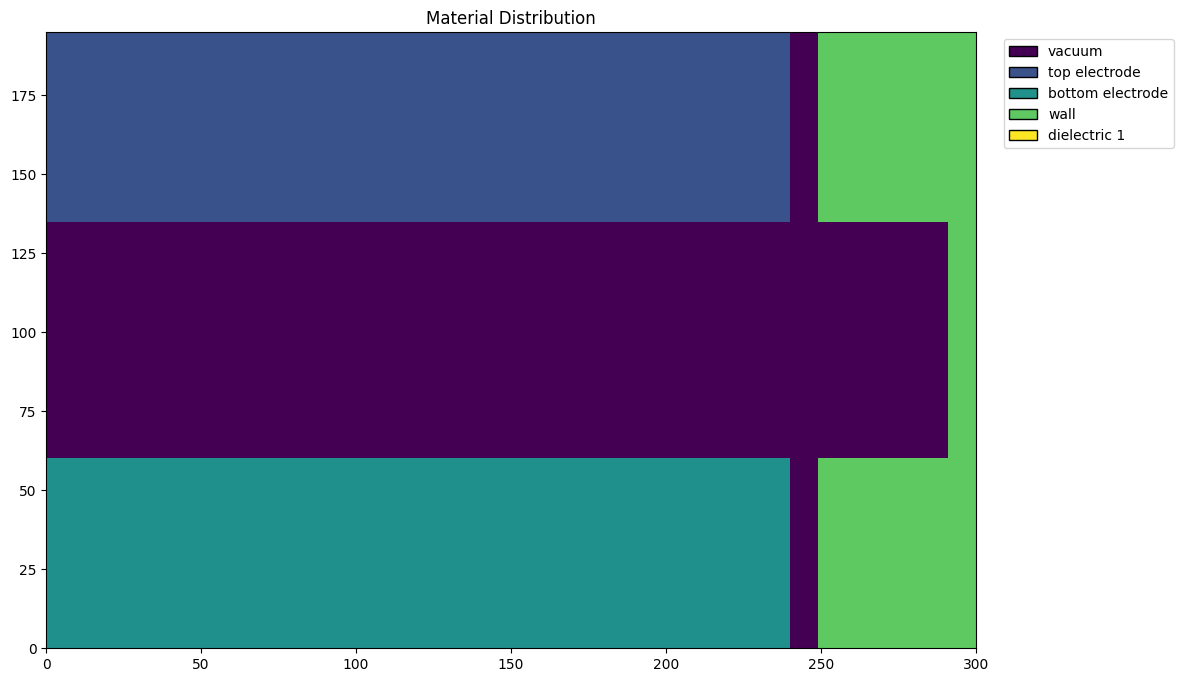

In [61]:
geom.show()

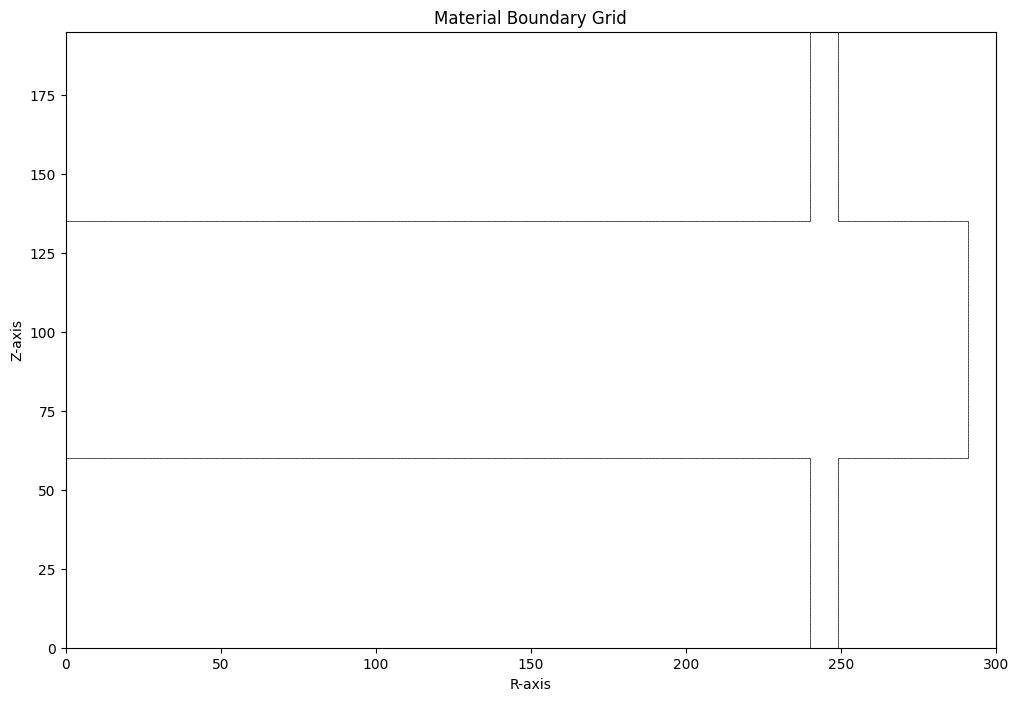

In [62]:
geom.show_grid()

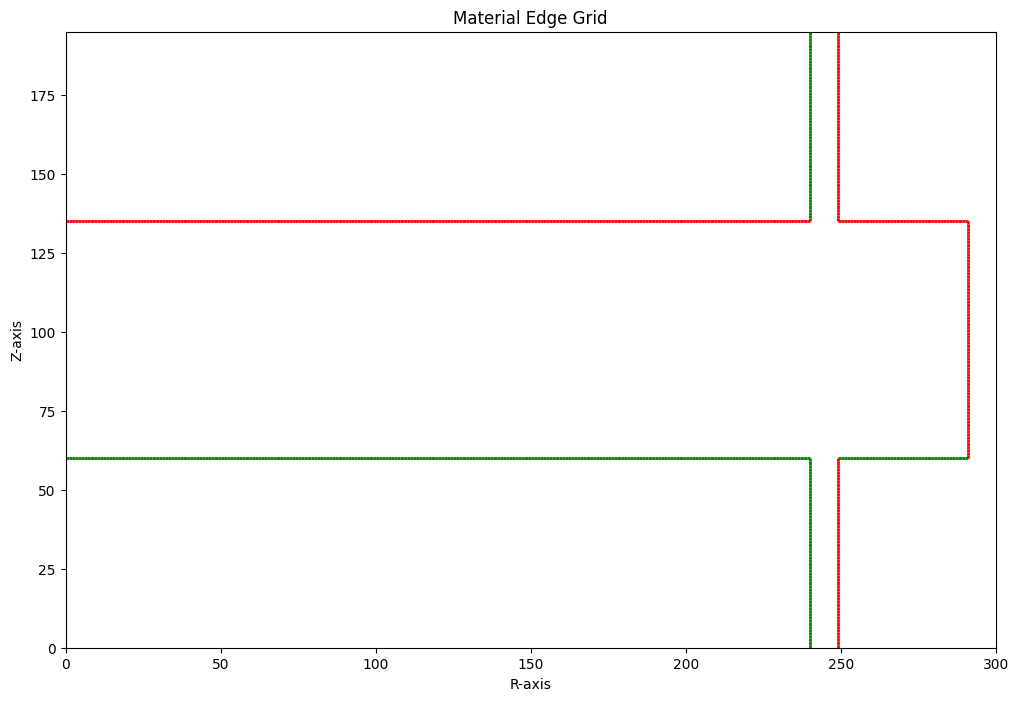

In [63]:
geom.update_edge_type()
geom.show_edge()

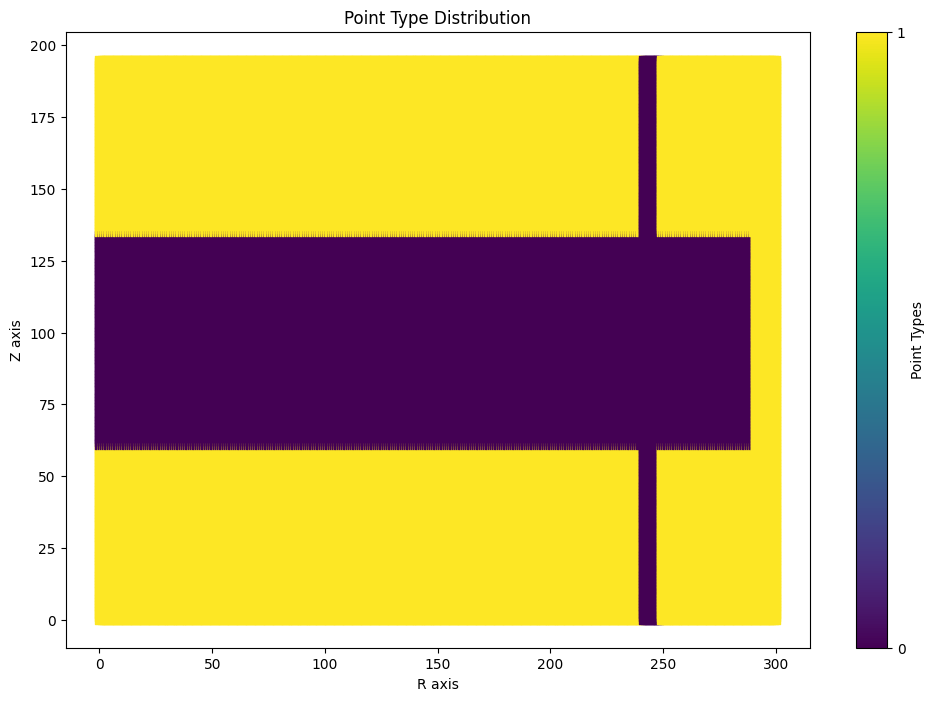

In [64]:
geom.update_point_type()
geom.show_point()

In [65]:
geom.update_epsilon()
geom.update_volume()

In [66]:
geom.save('../../input/')